## import neccesary libraries

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# from sklearn.metrics import plot_roc_curve
from sklearn.preprocessing import LabelEncoder

# # Data Collection

In [50]:
# Data Loading
df = pd.read_csv(r'Dataset\dataset.csv')
df

,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
0,138,8.6,560,7.46,0.62,0.70,5.90,0.24,0.31,0.77,8.71,0.11,0
1,213,7.5,338,7.62,0.75,1.06,25.40,0.30,0.86,1.54,2.89,2.29,0
2,163,9.6,718,7.59,0.51,1.11,14.30,0.30,0.86,1.57,2.70,2.03,0
3,157,6.8,475,7.64,0.58,0.94,26.00,0.34,0.54,1.53,2.65,1.82,0
4,270,9.9,444,7.63,0.40,0.86,11.80,0.25,0.76,1.69,2.43,2.26,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,326,10.3,507,7.88,0.71,0.39,8.75,0.21,8.63,2.01,8.63,0.32,1
837,351,10.7,623,7.96,0.51,0.29,7.24,0.36,4.69,0.69,11.03,0.69,1
838,264,9.0,486,7.24,0.47,0.10,3.92,0.35,8.26,0.45,7.98,0.40,1
839,276,9.2,370,7.62,0.62,0.49,6.64,0.42,3.57,0.63,6.48,0.32,1


In [51]:
#Printing the shape of the dataset 
df.shape

(841, 13)

In [52]:
#Getting the data types of all the columns
df.columns

Index(['N', 'P', 'K', 'pH', 'EC', 'OC', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B',
       'Output'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 841 entries, 0 to 840
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       841 non-null    int64  
 1   P       841 non-null    float64
 2   K       841 non-null    int64  
 3   pH      841 non-null    float64
 4   EC      841 non-null    float64
 5   OC      841 non-null    float64
 6   S       841 non-null    float64
 7   Zn      841 non-null    float64
 8   Fe      841 non-null    float64
 9   Cu      841 non-null    float64
 10  Mn      841 non-null    float64
 11  B       841 non-null    float64
 12  Output  841 non-null    int64  
dtypes: float64(10), int64(3)
memory usage: 85.5 KB


In [54]:
df.describe()

,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.00000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,243.199762,13.903805,499.430440,7.502342,0.544364,0.61648,7.601284,0.473698,4.155018,0.961902,8.666564,0.588038,0.523187
std,76.315233,20.992226,124.278729,0.452330,0.142616,0.85965,4.469312,1.937353,3.122870,0.465949,4.241489,0.574543,0.499759
min,6.000000,2.900000,11.000000,0.900000,0.100000,0.10000,0.640000,0.070000,0.210000,0.090000,0.110000,0.060000,0.000000
25%,201.000000,6.800000,412.000000,7.350000,0.430000,0.35000,4.800000,0.280000,2.120000,0.630000,6.230000,0.270000,0.000000
50%,251.000000,8.100000,475.000000,7.500000,0.550000,0.59000,6.640000,0.360000,3.560000,0.930000,8.340000,0.400000,1.000000
75%,301.000000,9.900000,581.000000,7.620000,0.640000,0.78000,8.750000,0.470000,6.320000,1.250000,11.360000,0.610000,1.000000
max,377.000000,122.800000,887.000000,10.600000,0.950000,24.00000,31.000000,42.000000,44.000000,3.020000,30.480000,2.820000,1.000000



Soil Fertility Data fields
Use elemetal soil analysis to determine the fertility of the soil.

Input
* N - ratio of Nitrogen (NH4+) content in soil
* P - ratio of Phosphorous (P) content in soil
* K - ratio of Potassium (K) content in soil
* ph - soil acidity (pH)
* ec - electrical conductivity
* oc - organic carbon
* S - sulfur (S)
* zn - Zinc (Zn)
* fe - Iron (Fe)
* cu - Copper (Cu)
* Mn - Manganese (Mn)
* B - Boron (B)

Output
* Class fertility: 
    - 0 => No Fertile is in soil
    - 1 => Fertile is in soil

In [55]:
df.duplicated().sum()

0

In [56]:
df.isnull().sum()

N         0
P         0
K         0
pH        0
EC        0
OC        0
S         0
Zn        0
Fe        0
Cu        0
Mn        0
B         0
Output    0
dtype: int64

In [57]:
df["Output"].value_counts()

Output
1    440
0    401
Name: count, dtype: int64

# # Data Splitting

In [58]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [59]:
x

,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B
0,138,8.6,560,7.46,0.62,0.70,5.90,0.24,0.31,0.77,8.71,0.11
1,213,7.5,338,7.62,0.75,1.06,25.40,0.30,0.86,1.54,2.89,2.29
2,163,9.6,718,7.59,0.51,1.11,14.30,0.30,0.86,1.57,2.70,2.03
3,157,6.8,475,7.64,0.58,0.94,26.00,0.34,0.54,1.53,2.65,1.82
4,270,9.9,444,7.63,0.40,0.86,11.80,0.25,0.76,1.69,2.43,2.26
...,...,...,...,...,...,...,...,...,...,...,...,...
836,326,10.3,507,7.88,0.71,0.39,8.75,0.21,8.63,2.01,8.63,0.32
837,351,10.7,623,7.96,0.51,0.29,7.24,0.36,4.69,0.69,11.03,0.69
838,264,9.0,486,7.24,0.47,0.10,3.92,0.35,8.26,0.45,7.98,0.40
839,276,9.2,370,7.62,0.62,0.49,6.64,0.42,3.57,0.63,6.48,0.32


In [60]:
y

0      0
1      0
2      0
3      0
4      1
      ..
836    1
837    1
838    1
839    1
840    0
Name: Output, Length: 841, dtype: int64

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# # Algorithm Implemendation

Accuracy of Random Forest :  95.25691699604744
The classificatin report for RandomForestClassifier :
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       112
           1       0.96      0.95      0.96       141

    accuracy                           0.95       253
   macro avg       0.95      0.95      0.95       253
weighted avg       0.95      0.95      0.95       253



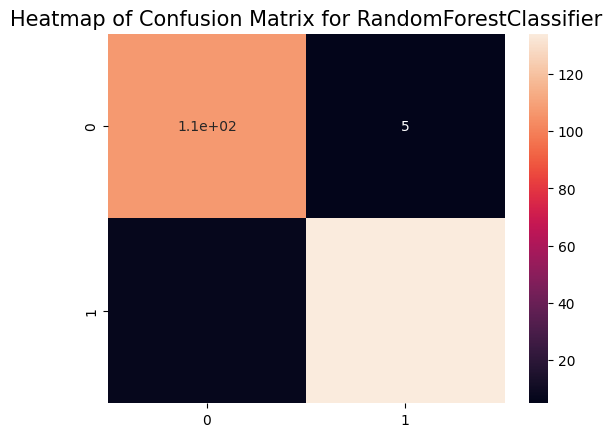

In [62]:
# Model Initializing
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier()

# Training
random_forest_model.fit(x_train,y_train)

# Testing
random_forest_y_pred = random_forest_model.predict(x_test)

# Accuracy
random_forest_accuracy = accuracy_score(random_forest_y_pred, y_test)
print("Accuracy of Random Forest : ", random_forest_accuracy*100)

# classificatin report
print('The classificatin report for RandomForestClassifier :')
report = classification_report(y_test, random_forest_y_pred)
print(report)

#confustion metrix
cm = confusion_matrix(y_test, random_forest_y_pred)
plt.title('Heatmap of Confusion Matrix for RandomForestClassifier', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Accuracy of Logistic Regression :  92.09486166007905
The classificatin report for Logistic Regression :
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       112
           1       0.92      0.94      0.93       141

    accuracy                           0.92       253
   macro avg       0.92      0.92      0.92       253
weighted avg       0.92      0.92      0.92       253



c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


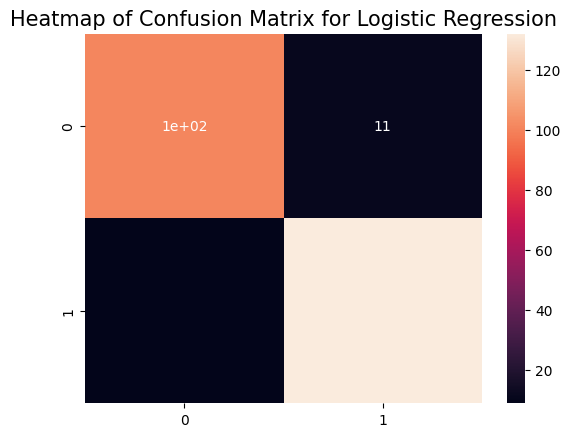

In [63]:
# Model Initializing
from sklearn.linear_model import LogisticRegression
Logistic_Regression_model = LogisticRegression()

# Training
Logistic_Regression_model.fit(x_train,y_train)

# Testing
Logistic_Regression_y_pred = Logistic_Regression_model.predict(x_test)

# Accuracy
Logistic_Regression_accuracy = accuracy_score(Logistic_Regression_y_pred, y_test)
print("Accuracy of Logistic Regression : ", Logistic_Regression_accuracy * 100)

# classificatin report
print('The classificatin report for Logistic Regression :')
report = classification_report(y_test, Logistic_Regression_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, Logistic_Regression_y_pred)
plt.title('Heatmap of Confusion Matrix for Logistic Regression', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Accuracy of MLP Classifier :  85.37549407114624
The classificatin report for MLP Classifier :
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       112
           1       0.91      0.82      0.86       141

    accuracy                           0.85       253
   macro avg       0.85      0.86      0.85       253
weighted avg       0.86      0.85      0.85       253



c:\Users\0877\.conda\envs\tk177065\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


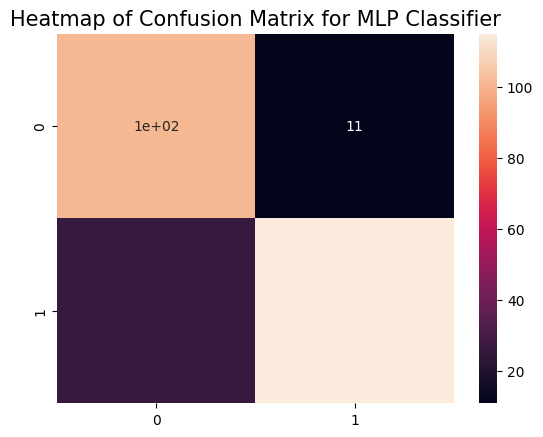

In [64]:
# Model Initializing
from sklearn.neural_network import MLPClassifier
MLP_Classifier_model = MLPClassifier()

# Training
MLP_Classifier_model.fit(x_train,y_train)

# Testing
MLP_Classifier_y_pred = MLP_Classifier_model.predict(x_test)

# Accuracy
MLP_Classifier_accuracy = accuracy_score(MLP_Classifier_y_pred, y_test)
print("Accuracy of MLP Classifier : ", MLP_Classifier_accuracy * 100)

# classificatin report
print('The classificatin report for MLP Classifier :')
report = classification_report(y_test, MLP_Classifier_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, MLP_Classifier_y_pred)
plt.title('Heatmap of Confusion Matrix for MLP Classifier', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Accuracy of SVC Classifier :  92.88537549407114
The classificatin report for SVC Classifier :
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       112
           1       0.93      0.94      0.94       141

    accuracy                           0.93       253
   macro avg       0.93      0.93      0.93       253
weighted avg       0.93      0.93      0.93       253



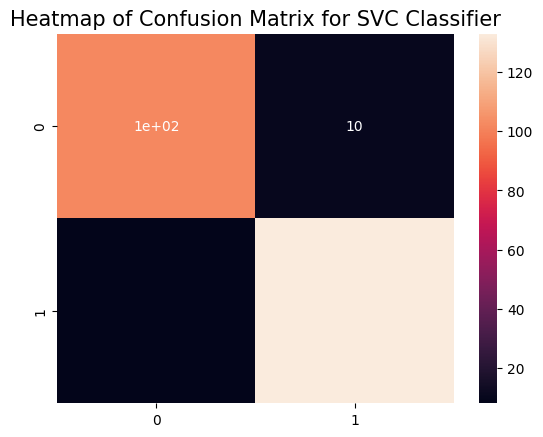

In [65]:
# Model Initializing
from sklearn.svm import SVC
svc_Classifier_model = SVC()

# Training
svc_Classifier_model.fit(x_train,y_train)

# Testing
svc_Classifier_y_pred = svc_Classifier_model.predict(x_test)

# Accuracy
svc_Classifier_accuracy = accuracy_score(svc_Classifier_y_pred, y_test)
print("Accuracy of SVC Classifier : ", svc_Classifier_accuracy * 100)

# classificatin report
print('The classificatin report for SVC Classifier :')
report = classification_report(y_test, svc_Classifier_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, svc_Classifier_y_pred)
plt.title('Heatmap of Confusion Matrix for SVC Classifier', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Accuracy of GNB Classifier :  62.055335968379445
The classificatin report for GNB Classifier :
              precision    recall  f1-score   support

           0       0.54      0.97      0.69       112
           1       0.94      0.34      0.50       141

    accuracy                           0.62       253
   macro avg       0.74      0.66      0.60       253
weighted avg       0.76      0.62      0.59       253



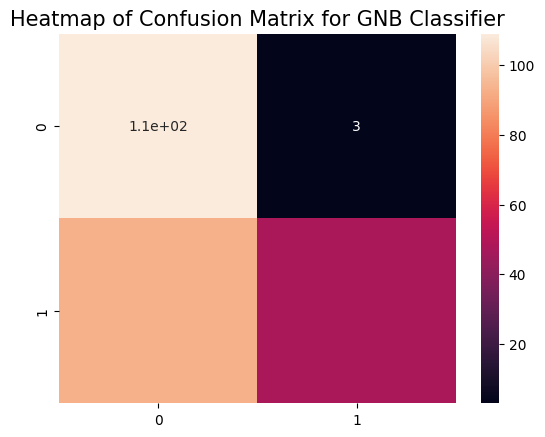

In [66]:
# Model Initializing
from sklearn.naive_bayes import GaussianNB
gnb_Classifier_model = GaussianNB()

# Training
gnb_Classifier_model.fit(x_train,y_train)

# Testing
gnb_Classifier_y_pred = gnb_Classifier_model.predict(x_test)

# Accuracy
gnb_Classifier_accuracy = accuracy_score(gnb_Classifier_y_pred, y_test)
print("Accuracy of GNB Classifier : ", gnb_Classifier_accuracy * 100)

# classificatin report
print('The classificatin report for GNB Classifier :')
report = classification_report(y_test, gnb_Classifier_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, gnb_Classifier_y_pred)
plt.title('Heatmap of Confusion Matrix for GNB Classifier', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

Learning rate set to 0.008212
0:	learn: 0.6815377	total: 154ms	remaining: 2m 33s
1:	learn: 0.6712577	total: 158ms	remaining: 1m 18s
2:	learn: 0.6617402	total: 162ms	remaining: 53.9s
3:	learn: 0.6539875	total: 166ms	remaining: 41.2s
4:	learn: 0.6443708	total: 168ms	remaining: 33.4s
5:	learn: 0.6349009	total: 170ms	remaining: 28.2s
6:	learn: 0.6242497	total: 172ms	remaining: 24.5s
7:	learn: 0.6158766	total: 175ms	remaining: 21.6s
8:	learn: 0.6075558	total: 177ms	remaining: 19.5s
9:	learn: 0.5994623	total: 179ms	remaining: 17.8s
10:	learn: 0.5918185	total: 182ms	remaining: 16.3s
11:	learn: 0.5836102	total: 184ms	remaining: 15.1s
12:	learn: 0.5747843	total: 186ms	remaining: 14.1s
13:	learn: 0.5672349	total: 188ms	remaining: 13.2s
14:	learn: 0.5598194	total: 190ms	remaining: 12.5s
15:	learn: 0.5523402	total: 192ms	remaining: 11.8s
16:	learn: 0.5439302	total: 195ms	remaining: 11.3s
17:	learn: 0.5367166	total: 197ms	remaining: 10.8s
18:	learn: 0.5286181	total: 199ms	remaining: 10.3s
19:	learn

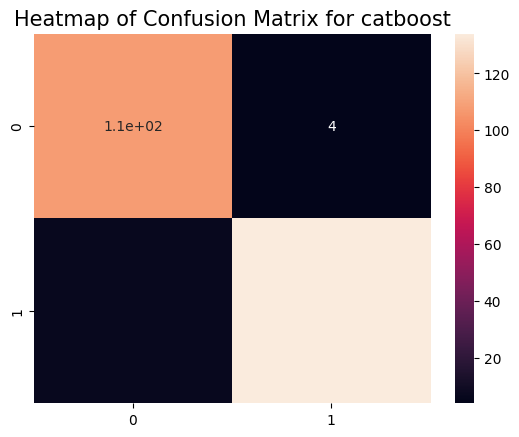

In [67]:
# Model Initializing
from catboost import CatBoostClassifier
catboost_model = CatBoostClassifier()

# Training
catboost_model.fit(x_train,y_train)

# Testing
catboost_y_pred = catboost_model.predict(x_test)

# Accuracy
catboost_accuracy = accuracy_score(catboost_y_pred, y_test)
print("Accuracy of catboost : ", catboost_accuracy * 100)

# classificatin report
print('The classificatin report for catboost :')
report = classification_report(y_test, catboost_y_pred)
print(report)

# confustion metrix
cm = confusion_matrix(y_test, catboost_y_pred)
plt.title('Heatmap of Confusion Matrix for catboost', fontsize = 15)
sns.heatmap(cm, annot = True)
plt.show()

## Model Comparision

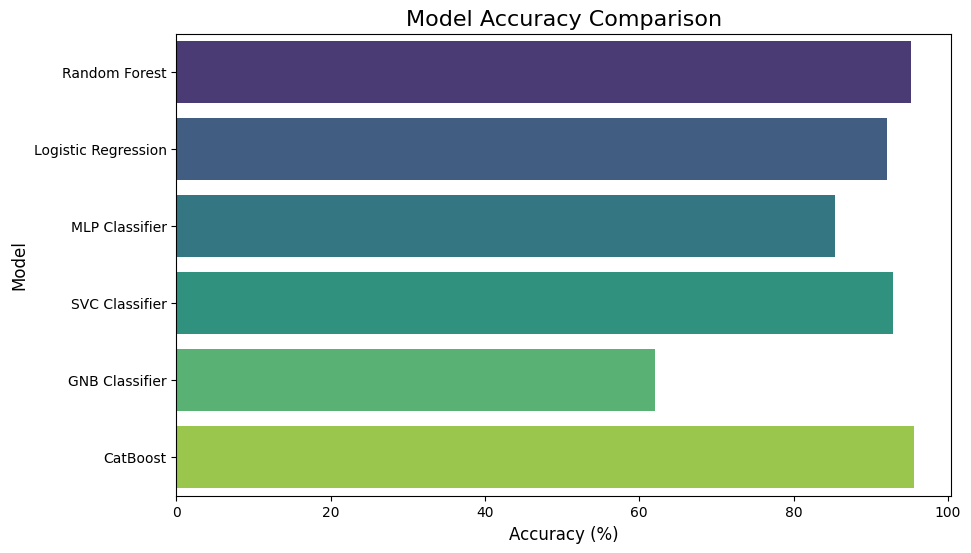

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect the model names and their respective accuracies
models = ['Random Forest', 'Logistic Regression', 'MLP Classifier', 'SVC Classifier', 
          'GNB Classifier', 'CatBoost']
accuracies = [random_forest_accuracy * 100, 
              Logistic_Regression_accuracy * 100, 
              MLP_Classifier_accuracy * 100, 
              svc_Classifier_accuracy * 100, 
              gnb_Classifier_accuracy * 100, 
              catboost_accuracy * 100]

# Create a DataFrame for the model comparison
model_comparison_df = pd.DataFrame({'Model': models, 'Accuracy': accuracies})

# Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=model_comparison_df, palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.show()

## Save model

In [69]:
# Save the trained models
import joblib

joblib.dump(random_forest_model, 'Models/random_forest_model.pkl')
joblib.dump(Logistic_Regression_model, 'Models/logistic_regression_model.pkl')
joblib.dump(MLP_Classifier_model, 'Models/mlp_classifier_model.pkl')
joblib.dump(svc_Classifier_model, 'Models/svc_classifier_model.pkl')
joblib.dump(gnb_Classifier_model, 'Models/gnb_classifier_model.pkl')
joblib.dump(catboost_model, 'Models/catboost_model.pkl')

['Models/catboost_model.pkl']

## Prediction Part

* Class fertility: 
    - 0 => No Fertile is in soil
    - 1 => Fertile is in soil

In [79]:
import joblib
import numpy as np
import pandas as pd

model = joblib.load(r'Models\catboost_model.pkl')

def get_user_input_and_predict(input_data):
    user_input = np.array([input_data])
    prediction = model.predict(user_input)
    if prediction == 0:
        print(f"Prediction: No Fertile is in soil")
    else:
        print(f"Prediction: Fertile is in soil")

### Example predictions

In [81]:
get_user_input_and_predict([138, 8.6, 560, 7.46, 0.62, 0.7, 5.9, 0.24, 0.31, 0.77, 8.71, 0.11])

Prediction: No Fertile is in soil


In [83]:
get_user_input_and_predict([270, 8.1, 655, 7.45, 0.55, 0.67, 10.2, 0.28, 0.44, 1.26, 7.75, 2.56])

Prediction: Fertile is in soil
